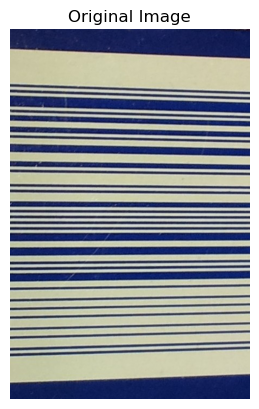

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('barcode_cropped.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')
plt.show()

(np.float64(-0.5), np.float64(445.5), np.float64(687.5), np.float64(-0.5))

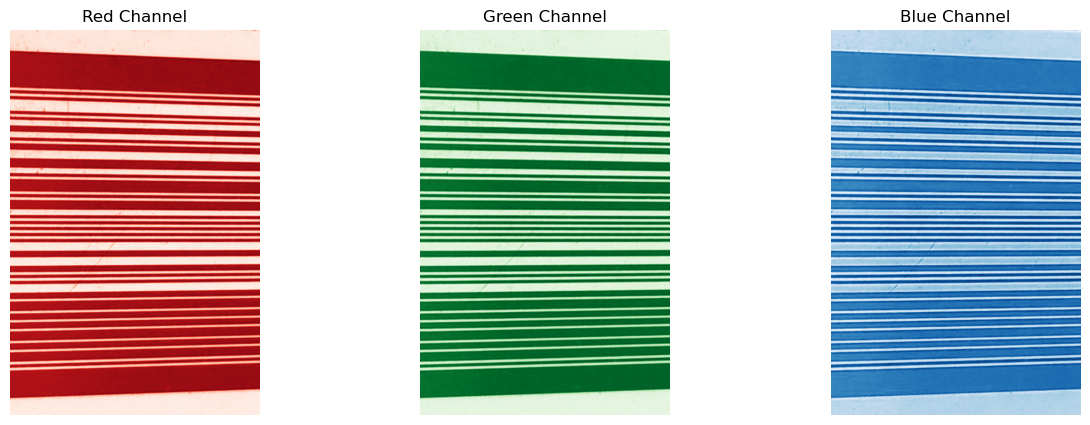

In [3]:
r,g,b = cv2.split(img_rgb)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(r, cmap='Reds')
plt.title('Red Channel')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(g, cmap='Greens')
plt.title('Green Channel')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(b, cmap='Blues')
plt.title('Blue Channel')
plt.axis('off')

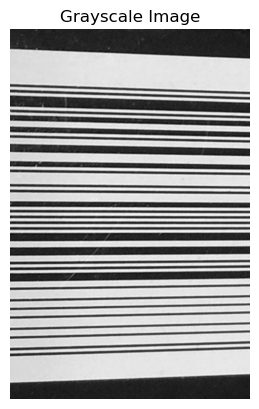

In [4]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

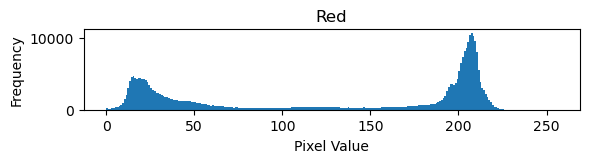

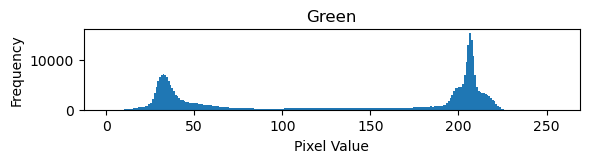

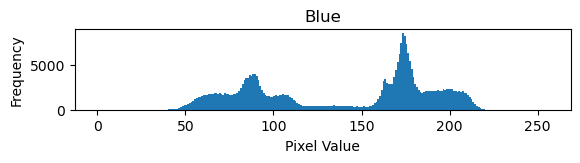

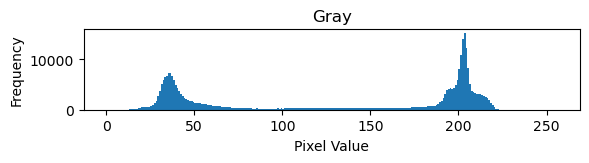

In [5]:
channels = [r, g, b, gray]
titles = ["Red", "Green", "Blue", "Gray"]

plt.figure()
for it, (channel, title) in enumerate(zip(channels, titles)):
    plt.subplot(4,1,it+1)
    plt.hist(channel.ravel(), bins=256, range=[0, 256])
    plt.title(title)
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.show()


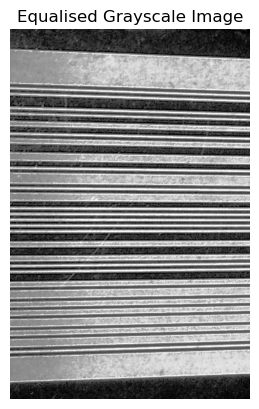

In [6]:
r_eq = cv2.equalizeHist(r)
g_eq = cv2.equalizeHist(g)
b_eq = cv2.equalizeHist(b)
gray_eq = cv2.equalizeHist(gray)

plt.imshow(gray_eq, cmap='gray')
plt.title("Equalised Grayscale Image")
plt.axis('off')
plt.show()

In [7]:
barcode = cv2.imread('barcode_cropped.jpg')
chocolate = cv2.imread('chocolate_original.jpg')

barcode_gray = cv2.cvtColor(barcode, cv2.COLOR_BGR2GRAY)
chocolate_gray = cv2.cvtColor(chocolate, cv2.COLOR_BGR2GRAY)

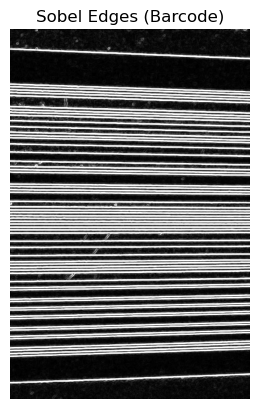

In [8]:
sobel_x = cv2.Sobel(barcode_gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(barcode_gray, cv2.CV_64F, 0, 1, ksize=3)

sobel = np.sqrt(sobel_x**2 + sobel_y**2)
sobel = np.uint8(np.clip(sobel, 0, 255))

plt.imshow(sobel, cmap='gray')
plt.title("Sobel Edges (Barcode)")
plt.axis("off")
plt.show()

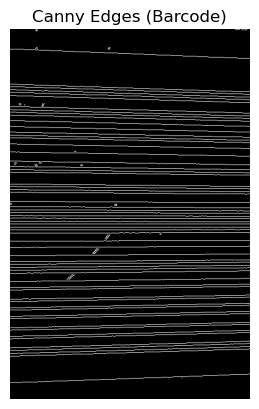

In [9]:
canny_barcode = cv2.Canny(barcode_gray, 100, 200)

plt.imshow(canny_barcode, cmap='gray')
plt.title("Canny Edges (Barcode)")
plt.axis("off")
plt.show()

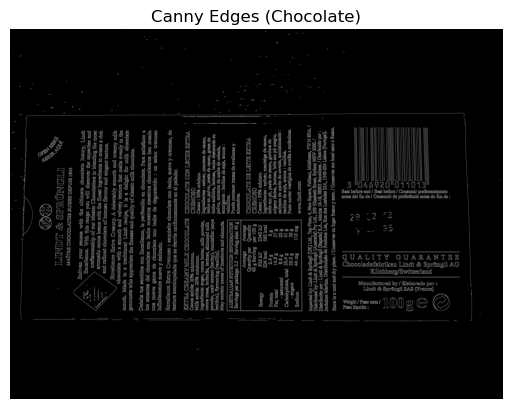

In [10]:
canny_chocolate = cv2.Canny(chocolate_gray, 100, 200)
plt.imshow(canny_chocolate, cmap='gray')
plt.title("Canny Edges (Chocolate)")
plt.axis('off')
plt.show()

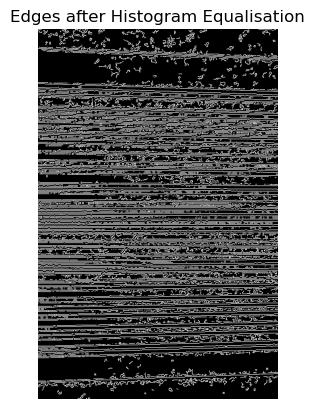

In [11]:
barcode_eq = cv2.equalizeHist(barcode_gray)
edges_eq = cv2.Canny(barcode_eq, 100, 200)

plt.imshow(edges_eq, cmap='gray')
plt.title("Edges after Histogram Equalisation")
plt.axis('off')
plt.show()

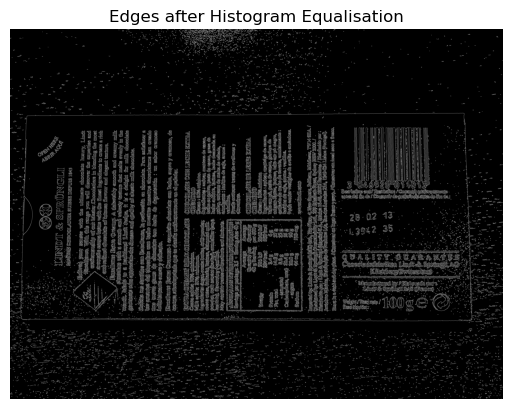

In [12]:
chocolate_eq = cv2.equalizeHist(chocolate_gray)
edges_eq = cv2.Canny(chocolate_eq, 100, 200)
plt.imshow(edges_eq, cmap='gray')
plt.title("Edges after Histogram Equalisation")
plt.axis('off')
plt.show()

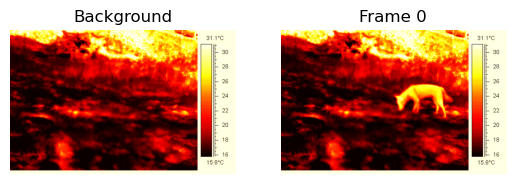

In [13]:
img1 = cv2.imread('DINGO3_Background.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('DINGO3_Frame0.jpg', cv2.IMREAD_GRAYSCALE)
plt.figure()
plt.subplot(1,2,1)
plt.imshow(img1, cmap='hot')
plt.title("Background")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(img2, cmap='hot')
plt.title("Frame 0")
plt.axis('off')
plt.show()

In [14]:
im_diff = img1.astype(np.float32) - img2.astype(np.float32)

print(f"Min difference: {np.min(im_diff)}, Max difference: {np.max(im_diff)}")

Min difference: -226.0, Max difference: 32.0


In [ ]:
min_val, max_val = np.min(im_diff), np.max(im_diff)
im_norm = (im_diff - min_val) / (max_val - min_val)
im_norm = (im_norm * 255).astype(np.uint8)
# print Min Max
print(f"Min Value {}")
im_norm_inverted = np.invert(im_norm)


Min normalized: 0, Max normalized: 255


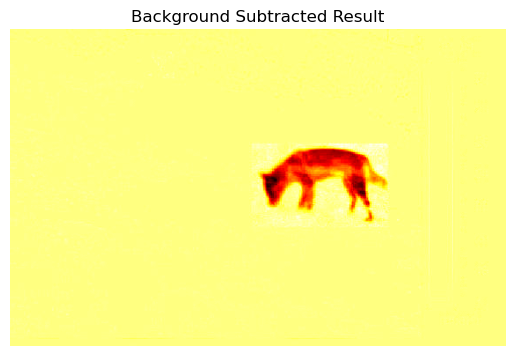

In [16]:
plt.imshow(im_norm,cmap='hot')
plt.title("Background Subtracted Result")
plt.axis('off')
plt.show()

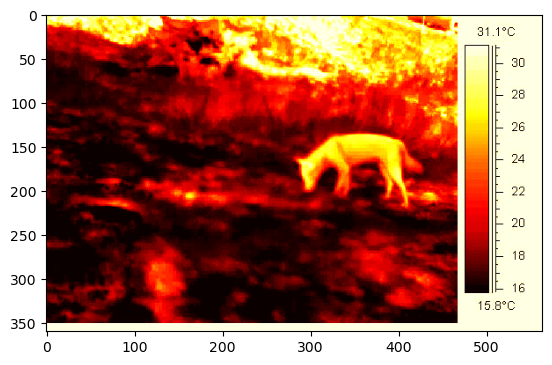

In [17]:
plt.imshow(img2, cmap='hot')